<a href="https://colab.research.google.com/github/sinJiNi1001/Pest-Identification/blob/main/Morphological_similarity__new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 126MB/s]


Extracting enhanced features from 10456 images...
Training SVM Classifier on 1792 features...

CLASSIFICATION METRICS
              precision    recall  f1-score   support

      aphids       0.84      0.88      0.86       210
   army worm       0.88      0.88      0.88       216
    ballwarm       0.96      0.99      0.97       204
      beetle       0.83      0.81      0.82       206
 grasshopper       0.87      0.78      0.82       205
       mites       0.90      0.84      0.87       208
  red spider       0.83      0.84      0.83       209
      sawfly       0.96      0.99      0.98       216
  stem borer       0.88      0.87      0.88       202
    whitefly       0.90      0.98      0.94       216

    accuracy                           0.89      2092
   macro avg       0.88      0.88      0.88      2092
weighted avg       0.88      0.89      0.88      2092



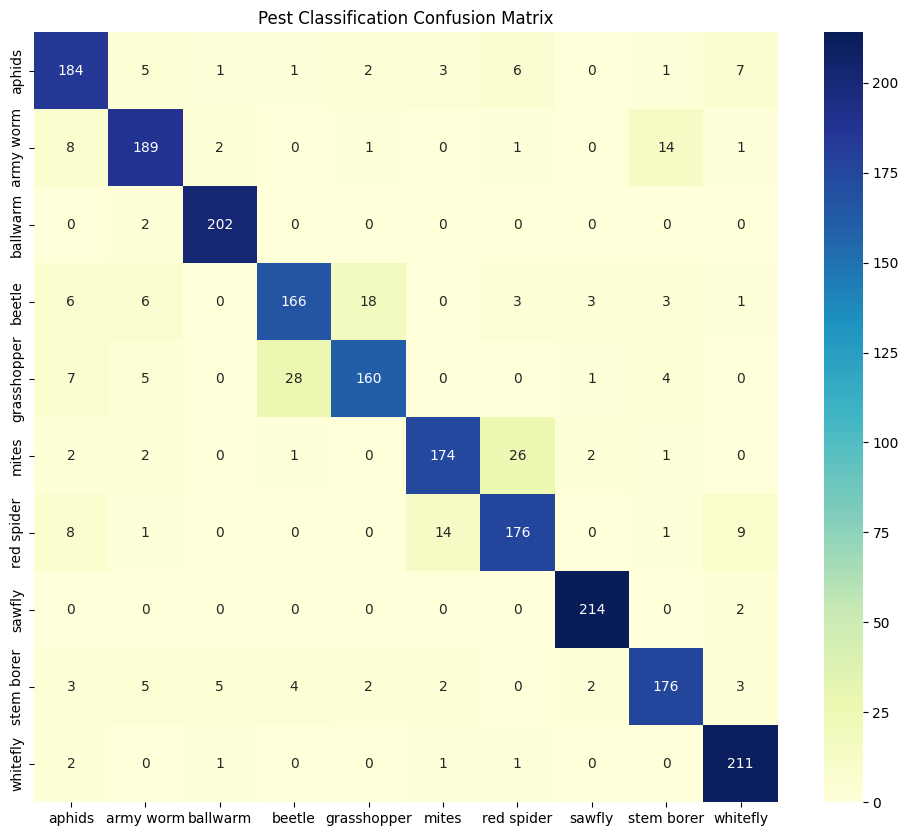

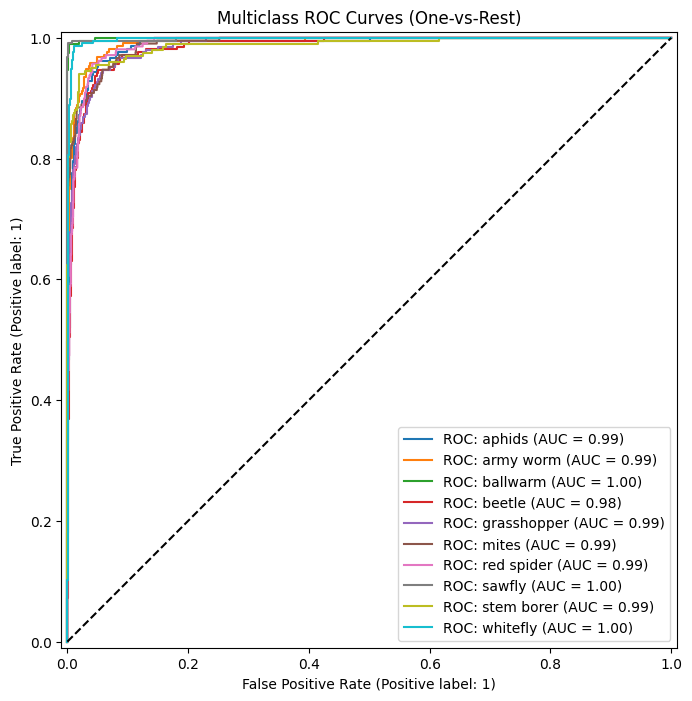


Overall Macro ROC-AUC Score: 0.9916


In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
from skimage.morphology import skeletonize
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from google.colab import drive, files

# 1. MOUNT DRIVE
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- CONFIGURATION ---
DATASET_PATH = '/content/drive/MyDrive/Pests_dataset ORIGINAL/Dataset'
IMG_SIZE = 224
BATCH_SIZE = 32

# 2. IMPROVED SKELETONIZATION (OTSU)
def get_skeleton(img_pil):
    img_np = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    gray = rgb2gray(img_np)
    try:
        # Otsu's thresholding is more robust than simple mean
        thresh = threshold_otsu(gray)
        binary = gray > thresh
    except ValueError: # Fallback if image is uniform
        binary = gray > 0.5

    skel = skeletonize(binary).astype(np.float32)
    skel_3ch = np.stack([skel]*3, axis=0)
    return torch.from_numpy(skel_3ch)

class HybridPestDataset(ImageFolder):
    def __getitem__(self, index):
        path, target = self.samples[index]
        sample = self.loader(path)

        transform_rgb = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        img_rgb = transform_rgb(sample)
        img_skel = get_skeleton(sample)
        return img_rgb, img_skel, target

# 3. UPGRADED FEATURE EXTRACTOR (ResNet + MobileNetV2)
class HybridFeatureExtractor(nn.Module):
    def __init__(self):
        super(HybridFeatureExtractor, self).__init__()

        # Branch 1: Structural (ResNet18) - Weights updated to modern API
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.structural_net = nn.Sequential(*list(resnet.children())[:-1]) # Output: 512

        # Branch 2: Texture (MobileNetV2) - Deeper but mobile-friendly
        mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.texture_net = nn.Sequential(*list(mobilenet.features), nn.AdaptiveAvgPool2d((1, 1))) # Output: 1280

    def forward(self, x_rgb, x_skel):
        feat_struct = self.structural_net(x_skel).view(x_skel.size(0), -1)
        feat_textur = self.texture_net(x_rgb).view(x_rgb.size(0), -1)
        # Final Concatenated Vector: 512 + 1280 = 1792 features
        return torch.cat((feat_struct, feat_textur), dim=1)

# 4. FIXED MULTICLASS EVALUATION
def evaluate_model(svm, X_test, y_test, class_names):
    y_pred = svm.predict(X_test)
    y_score = svm.predict_proba(X_test)

    print("\n" + "="*30)
    print("CLASSIFICATION METRICS")
    print("="*30)
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Confusion Matrix
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='YlGnBu')
    plt.title("Pest Classification Confusion Matrix")
    plt.show()

    # Multiclass ROC-AUC Plot
    lb = LabelBinarizer().fit(y_test)
    y_test_bin = lb.transform(y_test)

    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(class_names):
        RocCurveDisplay.from_predictions(y_test_bin[:, i], y_score[:, i],
                                         name=f"ROC: {class_name}", ax=plt.gca())

    plt.plot([0, 1], [0, 1], "k--")
    plt.title("Multiclass ROC Curves (One-vs-Rest)")
    plt.show()

    auc = roc_auc_score(y_test, y_score, multi_class='ovr')
    print(f"\nOverall Macro ROC-AUC Score: {auc:.4f}")

# 5. EXECUTION PIPELINE
def run_full_pipeline():
    dataset = HybridPestDataset(root=DATASET_PATH)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    class_names = dataset.classes

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    extractor = HybridFeatureExtractor().to(device).eval()

    features_list, labels_list = [], []

    print(f"Extracting enhanced features from {len(dataset)} images...")
    with torch.no_grad():
        for imgs_rgb, imgs_skel, labels in loader:
            feats = extractor(imgs_rgb.to(device), imgs_skel.to(device))
            features_list.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())

    X = np.vstack(features_list)
    y = np.concatenate(labels_list)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"Training SVM Classifier on 1792 features...")
    svm = SVC(kernel='rbf', probability=True, random_state=42)
    svm.fit(X_train, y_train)

    # Save
    joblib.dump(svm, 'pest_svm_model.pkl')
    torch.save(extractor.state_dict(), 'feature_extractor.pth')

    evaluate_model(svm, X_test, y_test, class_names)
    return extractor, svm, class_names

# Run
extractor, svm, classes = run_full_pipeline()


--- Model Loaded Successfully ---
Ready to identify: aphids, army worm, ballwarm, beetle, grasshopper, mites, red spider, sawfly, stem borer, whitefly


Saving 14221.jpg to 14221.jpg


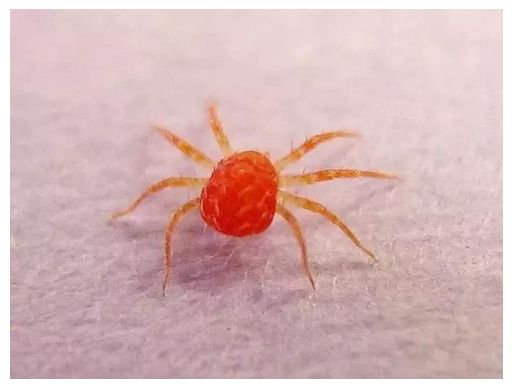


[ANALYSIS COMPLETE]
Target Filename: 14221.jpg
Detected Pest  : RED SPIDER
Confidence     : 91.89%
------------------------------


In [ ]:
import torch
import joblib
from PIL import Image
import numpy as np
from google.colab import files

def load_and_predict(class_names):
    # 1. SETUP HARDWARE & MODELS
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize and load the Feature Extractor
    extractor = HybridFeatureExtractor().to(device)
    extractor.load_state_dict(torch.load('feature_extractor.pth', map_location=device))
    extractor.eval()

    # Load the SVM Classifier
    svm = joblib.load('pest_svm_model.pkl')

    print("\n--- Model Loaded Successfully ---")
    print(f"Ready to identify: {', '.join(class_names)}")

    # 2. UPLOAD INTERFACE
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Open and show the image
        img = Image.open(filename).convert('RGB')
        plt.imshow(img)
        plt.axis('off')
        plt.show()

        # 3. PREPROCESS
        # Texture Branch Preprocessing
        transform_rgb = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        rgb_t = transform_rgb(img).unsqueeze(0).to(device)
        skel_t = get_skeleton(img).unsqueeze(0).to(device)

        # 4. INFERENCE
        with torch.no_grad():
            # Extract the 1792 features
            features = extractor(rgb_t, skel_t)
            features_np = features.cpu().numpy()

            # Predict using SVM
            probabilities = svm.predict_proba(features_np)[0]
            prediction_idx = np.argmax(probabilities)
            confidence = probabilities[prediction_idx]

        # 5. DISPLAY RESULTS
        result_label = class_names[prediction_idx]
        print(f"\n[ANALYSIS COMPLETE]")
        print(f"Target Filename: {filename}")
        print(f"Detected Pest  : {result_label.upper()}")
        print(f"Confidence     : {confidence*100:.2f}%")
        print("-" * 30)

# EXECUTE PREDICTION
# Note: Ensure 'classes' variable from your training run is available
load_and_predict(classes)